# Calculating SPI-3 for Seville's CMIP6 SSP5-8.5 Projection (2026-2045)

Computes the 3-month Standardised Precipitation Index (SPI-3) for Seville's projected precipitation,
using the same methodology as `Calculating_SPI_for_Seville.ipynb` -- a gamma distribution fit per
calendar month on the **fixed ERA5 1990-2020 reference period**, never refit on projection data (per
`fixed_reference_period_principle.md`, and matching how `seville_cmip6_projection_eda.ipynb` Section 6
already reuses a fixed ERA5 threshold rather than refitting one from the projection). That deferral was
explicit in that notebook's own scope notes -- `min_spi3` for the projection period was flagged as
"deferred, not attempted here." This notebook picks that up.

**Source data:** scoped to **2026-2045 only**, matching `seville_cmip6_projection_eda.ipynb`'s own
scope -- not the full 2026-2061 extension. Both series come from that notebook's own pipeline: the raw
grid-averaged pull (`data/seville_cmip6_ssp585_2026_2045.csv`, via
`cmip6_grid_processing.grid_average_daily`) and its Section 12 bias-corrected daily export
(`eda_results/eda_outputs_seville_projection/seville_projection_daily_biascorrected_2026_2045.csv`).
This matters beyond just the date range: that correction's Equidistant CDF Matching computes each
future value's quantile (tau) *relative to the model's own future distribution* -- and "the model's
own future distribution" is a different, narrower set of values when it's 2026-2045 alone vs. the full
2026-2061 extension used by the standalone `bias_correct_cmip6_projection.py` script. So this isn't
just a truncation of the earlier 2026-2061 results -- it's a genuinely different correction, fit
consistently with the rest of the EDA notebook's own 2026-2045 scope.

**Why both raw and corrected series, not just the corrected one:** working through
`seville_cmip6_projection_eda.ipynb` surfaced that `precip_total`'s bias correction is large (raw
~248mm/yr -> corrected ~454mm/yr, matching ERA5's own ~487mm/yr historical average) and
*multiplicative*, which means it doesn't shift every month by the same amount -- it scales some months
far more than others. Since SPI is a standardized-anomaly index scored against ERA5's real historical
distribution, feeding it the raw (systematically too-dry) series would read as a spurious permanent
drought signal that's really just the model's own bias, not a climate signal -- so using the corrected
series is the right call. But the multiplicative correction can also *amplify* already-wet months
disproportionately, which could show up as artificially extreme wet spikes in SPI-3. Section 2 checks
how large and how systematic that effect actually is before Sections 3-7 build SPI-3 on top of it, and
Section 6 checks whether that effect is visible in the SPI-3 output itself.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

from cmip6_grid_processing import grid_average_daily

pd.set_option("display.width", 140)

RAW_CSV = Path("data/seville_cmip6_ssp585_2026_2045.csv")
CORRECTED_CSV = Path("eda_results/eda_outputs_seville_projection/seville_projection_daily_biascorrected_2026_2045.csv")
ERA5_MONTHLY_CSV = Path("eda_results/eda_outputs/seville_monthly.csv")
OUT = Path("eda_results/eda_outputs_seville_projection")
OUT.mkdir(parents=True, exist_ok=True)

REFERENCE_START, REFERENCE_END = 1990, 2020  # fixed reference period -- never refit, see intro
PROJ_START, PROJ_END = 2026, 2045
ZERO_EPS = 1e-6  # values at/below this are treated as "zero" for the mixed distribution


## 1. Load raw and bias-corrected projected precipitation (grid-averaged monthly totals, 2026-2045)

Both series are built the same way `seville_cmip6_projection_eda.ipynb` builds its own daily frames --
`grid_average_daily()` for the raw pull (which also clips the near-zero floating-point negative noise
discussed earlier in that notebook's physical-plausibility check), and the bias-corrected CSV is
already a single grid-level daily series. Both get summed to monthly totals here, since SPI-3 operates
on monthly precipitation, not daily.


In [2]:
raw_daily = grid_average_daily(RAW_CSV)

corrected_daily = pd.read_csv(CORRECTED_CSV, parse_dates=["valid_time"])

raw_monthly = raw_daily.groupby(["year", "month"])["precip_mm_day"].sum().rename("raw_mm").reset_index()
corr_monthly = corrected_daily.groupby(["year", "month"])["precip_mm_day"].sum().rename("corrected_mm").reset_index()

monthly = raw_monthly.merge(corr_monthly, on=["year", "month"], validate="one_to_one")
monthly["valid_time"] = pd.to_datetime(dict(year=monthly["year"], month=monthly["month"], day=1))
monthly = monthly.sort_values("valid_time").reset_index(drop=True)

print(f"Monthly records: {len(monthly)}  ({monthly['valid_time'].min().date()} to {monthly['valid_time'].max().date()})")
monthly.head(6)


Monthly records: 240  (2026-01-01 to 2045-12-01)


,year,month,raw_mm,corrected_mm,valid_time
0,2026,1,59.329345,118.066360,2026-01-01
1,2026,2,0.142418,0.014777,2026-02-01
2,2026,3,54.190697,67.994723,2026-03-01
3,2026,4,68.159633,85.299525,2026-04-01
4,2026,5,3.311455,1.795747,2026-05-01
5,2026,6,0.806665,0.080666,2026-06-01


## 2. Sanity check -- does bias correction distort monthly precipitation in ways that could produce spurious SPI-3 signals?

The correction is multiplicative (`ratio = obs_at_tau / hist_at_tau`, clipped to [0.1, 10.0] --
see `bias_correct_cmip6_projection.py`), so it doesn't shift every month equally. Checking the
actual monthly ratio distribution below, before building SPI-3 on top of it.


Ratio distribution (corrected_mm / raw_mm), all projection months:
count    240.00
mean       1.39
std        0.96
min        0.10
25%        0.50
50%        1.28
75%        2.21
max        4.19
Name: ratio, dtype: float64

Months at/near the clip floor (ratio <= 0.11): 32 of 240
Months at/near the clip ceiling (ratio >= 9.9): 0 of 240

Top 15 months by amplification ratio:
 year  month  raw_mm  corrected_mm  ratio
 2037      9   10.28         43.06   4.19
 2031      9   60.02        234.31   3.90
 2026      9   20.01         72.22   3.61
 2039      9   19.05         64.59   3.39
 2027      1    3.86         12.43   3.22
 2033      9   30.82         97.29   3.16
 2031      1   17.30         52.46   3.03
 2032      1    7.54         21.98   2.91
 2043      9   22.89         65.84   2.88
 2038     12    6.21         17.65   2.84
 2042      9    7.77         22.05   2.84
 2032     10   13.52         37.99   2.81
 2029      1    0.65          1.82   2.81
 2042      1    3.92         10.78 

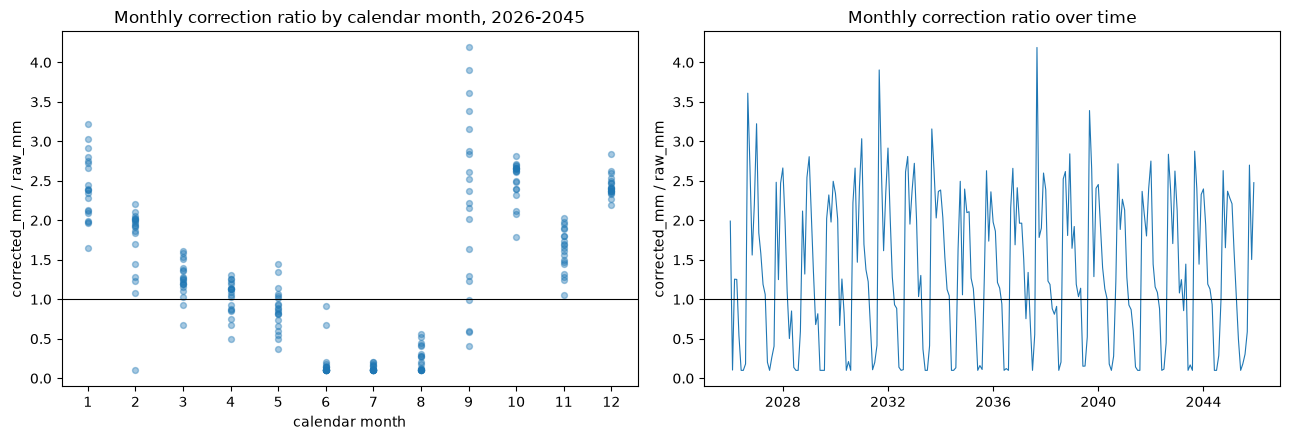

In [3]:
monthly["ratio"] = monthly["corrected_mm"] / monthly["raw_mm"].replace(0, np.nan)

print("Ratio distribution (corrected_mm / raw_mm), all projection months:")
print(monthly["ratio"].describe().round(2))
print()
print(f"Months at/near the clip floor (ratio <= 0.11): {(monthly['ratio'] <= 0.11).sum()} of {len(monthly)}")
print(f"Months at/near the clip ceiling (ratio >= 9.9): {(monthly['ratio'] >= 9.9).sum()} of {len(monthly)}")

print("\nTop 15 months by amplification ratio:")
print(monthly.sort_values("ratio", ascending=False)[["year", "month", "raw_mm", "corrected_mm", "ratio"]]
      .head(15).round(2).to_string(index=False))

print("\nBottom 15 months by ratio (largest reduction):")
print(monthly.sort_values("ratio", ascending=True)[["year", "month", "raw_mm", "corrected_mm", "ratio"]]
      .head(15).round(2).to_string(index=False))

print("\nCalendar-month breakdown of the top 20 amplification ratios:")
print(monthly.sort_values("ratio", ascending=False).head(20)["month"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(monthly["month"], monthly["ratio"], alpha=0.4, s=18, color="tab:blue")
axes[0].axhline(1.0, color="black", linewidth=0.8)
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel("calendar month")
axes[0].set_ylabel("corrected_mm / raw_mm")
axes[0].set_title("Monthly correction ratio by calendar month, 2026-2045")

axes[1].plot(monthly["valid_time"], monthly["ratio"], color="tab:blue", linewidth=0.8)
axes[1].axhline(1.0, color="black", linewidth=0.8)
axes[1].set_ylabel("corrected_mm / raw_mm")
axes[1].set_title("Monthly correction ratio over time")
plt.tight_layout()
plt.show()


### 2.1 Finding

Two distinct, explainable patterns, neither of which looks like a computation error:

- **Amplification (ratio > 1) concentrates in September, January, and October** -- 19 of the top 20
  amplification-ratio months fall in those three calendar months (7 September, 7 January, 5 October),
  across many different projection years (2026, 2027, 2029, 2031-2033, 2037-2039, 2042-2044), not just
  one or two outlier years. This lines up with the diagnostics from `seville_cmip6_projection_eda.ipynb`
  Section 12: `cmcc_esm2` under-simulates autumn/winter rain vs. ERA5, and because these are naturally
  low-precipitation months to begin with, the same proportional under-simulation produces a much larger
  *ratio* there than it does in a wetter month like December (which has the largest *absolute* mm/day
  bias, but a much smaller ratio because its baseline is already high). Max ratio observed is 4.19 --
  nowhere near the 10.0 clip ceiling.
- **Reduction (ratio < 1) concentrates in June-August, and hits the 0.1 clip floor often** -- 32 of 240
  months (13%) sit at or near the floor, almost entirely summer months where raw totals are already
  under 2mm for the whole month. `cmcc_esm2` runs *slightly* wetter than ERA5 in summer (see Section
  12's per-month bias table), so correction pulls these already-tiny values toward zero. This is
  low-risk for SPI-3 specifically: Seville summers are treated as effectively rainless by the SPI
  methodology's zero-inflated mixed distribution either way (see Section 4 below), so pushing an
  already-near-zero month closer to zero is unlikely to change its SPI-3 classification.

**What to watch for in Section 6:** the September/January/October amplification is the pattern worth
checking against the actual SPI-3 output, since those months carry real weight in 3-month windows that
overlap autumn/winter (e.g. Aug-Sep-Oct, Sep-Oct-Nov, Nov-Dec-Jan) -- unlike the summer reduction, which
mostly reinforces an already-correct "near zero" signal rather than distorting one.


## 3. Build the 3-month rolling SPI-3 input series (`precip_3mo`)

Same construction as `Calculating_SPI_for_Seville.ipynb` Section 1 -- a rolling 3-month sum of the
monthly total -- computed for both `raw_mm` and `corrected_mm` so Section 6 can compare the two SPI-3
outputs directly.


In [4]:
monthly["precip_3mo_raw"] = monthly["raw_mm"].rolling(window=3, min_periods=3).sum()
monthly["precip_3mo_corrected"] = monthly["corrected_mm"].rolling(window=3, min_periods=3).sum()

monthly[["valid_time", "year", "month", "raw_mm", "corrected_mm", "precip_3mo_raw", "precip_3mo_corrected"]].head(6)


,valid_time,year,month,raw_mm,corrected_mm,precip_3mo_raw,precip_3mo_corrected
0,2026-01-01,2026,1,59.329345,118.066360,NaN,NaN
1,2026-02-01,2026,2,0.142418,0.014777,NaN,NaN
2,2026-03-01,2026,3,54.190697,67.994723,113.662460,186.075861
3,2026-04-01,2026,4,68.159633,85.299525,122.492748,153.309025
4,2026-05-01,2026,5,3.311455,1.795747,125.661784,155.089995
5,2026-06-01,2026,6,0.806665,0.080666,72.277752,87.175938


## 4. Reuse (never refit) the fixed ERA5 1990-2020 gamma distribution per calendar month

Identical `fit_month_distribution`/`spi_from_distribution` logic to `Calculating_SPI_for_Seville.ipynb`
Section 2 -- reused here rather than re-derived, and fit on ERA5's own `seville_monthly.csv`
(`precip_mm_scaled`, the same input that notebook uses), restricted to the same fixed 1990-2020
reference period. The projection data is never used to fit this distribution -- only to be scored
against it in Section 5, per `fixed_reference_period_principle.md`.


In [5]:
def fit_month_distribution(ref_values):
    ref_values = np.asarray(ref_values, dtype=float)
    ref_values = ref_values[~np.isnan(ref_values)]
    zeros = ref_values <= ZERO_EPS
    q = zeros.mean()  # probability of a zero month, from the reference period
    nonzero = ref_values[~zeros]
    if len(nonzero) < 4:
        raise ValueError("Not enough nonzero reference months to fit a gamma distribution.")
    shape, loc, scale = stats.gamma.fit(nonzero, floc=0)
    return {"q": q, "shape": shape, "scale": scale}


def spi_from_distribution(x, dist):
    x = np.asarray(x, dtype=float)
    q, shape, scale = dist["q"], dist["shape"], dist["scale"]
    cdf = np.where(
        x <= ZERO_EPS,
        q,
        q + (1 - q) * stats.gamma.cdf(x, shape, loc=0, scale=scale),
    )
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
    return stats.norm.ppf(cdf)


era5_monthly = pd.read_csv(ERA5_MONTHLY_CSV, parse_dates=["valid_time"])
era5_monthly["precip_3mo"] = era5_monthly["precip_mm_scaled"].rolling(window=3, min_periods=3).sum()

era5_reference = era5_monthly[era5_monthly["year"].between(REFERENCE_START, REFERENCE_END)]

month_distributions = {}
for m in range(1, 13):
    ref_vals = era5_reference.loc[era5_reference["month"] == m, "precip_3mo"].dropna().values
    month_distributions[m] = fit_month_distribution(ref_vals)

print("Fitted reference-period (1990-2020) distribution per calendar month (reused from ERA5, not refit):")
pd.DataFrame(month_distributions).T.rename_axis("month").round(4)


Fitted reference-period (1990-2020) distribution per calendar month (reused from ERA5, not refit):


,q,shape,scale
month,,,
1,0.0,2.0408,93.8617
2,0.0,1.7841,99.8127
3,0.0,2.7719,55.2696
4,0.0,5.3015,29.0634
5,0.0,6.4158,22.0215
6,0.0,4.7273,19.8820
7,0.0,1.3050,33.5586
8,0.0,0.8873,13.6293
9,0.0,1.4157,25.3745


## 5. Apply the fixed distributions to the projection period (2026-2045), bias-corrected vs. raw

Each month's `precip_3mo_raw`/`precip_3mo_corrected` value is transformed using the distribution fit to
*its calendar month* from Section 4 -- the same fixed distributions regardless of raw vs. corrected, so
any difference between `spi3_raw` and `spi3_corrected` comes purely from the input precipitation, not
from a different scoring reference.


In [6]:
def compute_spi3(value, month):
    if pd.isna(value):
        return np.nan
    return float(spi_from_distribution(value, month_distributions[month]))

monthly["spi3_raw"] = monthly.apply(lambda r: compute_spi3(r["precip_3mo_raw"], r["month"]), axis=1)
monthly["spi3_corrected"] = monthly.apply(lambda r: compute_spi3(r["precip_3mo_corrected"], r["month"]), axis=1)

n_scored = monthly["spi3_corrected"].notna().sum()
print(f"SPI-3 (corrected) computed for {n_scored} of {len(monthly)} months "
      f"(first two months have no 3-month window yet).")

monthly[["valid_time", "year", "month", "precip_3mo_raw", "spi3_raw", "precip_3mo_corrected", "spi3_corrected"]].tail(8)


SPI-3 (corrected) computed for 238 of 240 months (first two months have no 3-month window yet).


,valid_time,year,month,precip_3mo_raw,spi3_raw,precip_3mo_corrected,spi3_corrected
232,2045-05-01,2045,5,94.589689,-0.816637,134.831825,0.015028
233,2045-06-01,2045,6,32.179397,-1.814446,30.289942,-1.908296
234,2045-07-01,2045,7,18.872585,-0.533800,4.008823,-1.645578
235,2045-08-01,2045,8,16.704825,0.671226,2.876195,-0.711876
236,2045-09-01,2045,9,14.630732,-0.631759,2.848812,-1.828212
237,2045-10-01,2045,10,18.234460,-2.132673,47.653792,-0.976745
238,2045-11-01,2045,11,56.908839,-1.622854,106.190382,-0.629347
239,2045-12-01,2045,12,148.436940,-0.437308,333.563269,1.168832


## 6. Does the bias correction change the SPI-3 signal? Revisiting the sanity check via SPI-3 itself

Section 2 found the correction amplifies September/January precipitation by up to ~4.5x in some years.
This section checks whether that shows up as a distortion in the SPI-3 output, or gets absorbed without
much practical effect once precipitation is standardized against its own calendar-month distribution.


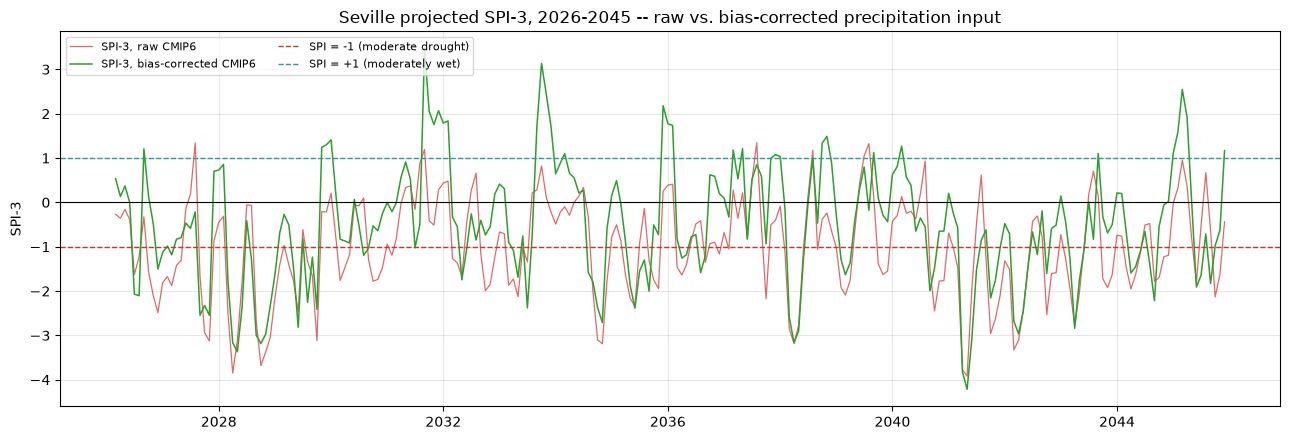

spi3_corrected - spi3_raw, across all scored months:
count    238.000
mean       0.511
std        0.854
min       -1.556
25%       -0.047
50%        0.696
75%        1.114
max        2.468
dtype: float64

SPI-3 (corrected) for the Section 2 top-amplification months (mostly September):
 year  month  ratio  spi3_raw  spi3_corrected
 2037      9   4.19     -0.55            0.59
 2031      9   3.90      1.19            3.47
 2026      9   3.61     -0.33            1.21
 2039      9   3.39      0.14            1.12
 2027      1   3.22     -1.81           -1.13
 2033      9   3.16      0.28            1.71
 2031      1   3.03     -0.94           -0.00
 2032      1   2.91      0.44            1.79
 2043      9   2.88      0.15            1.10
 2038     12   2.84     -0.65            0.90
 2042      9   2.84     -0.77           -0.19
 2032     10   2.81     -1.99           -0.73
 2029      1   2.81     -2.14           -1.62
 2042      1   2.75     -1.32           -0.48
 2033      1   2.72     

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(monthly["valid_time"], monthly["spi3_raw"], color="tab:red", linewidth=0.9, alpha=0.7, label="SPI-3, raw CMIP6")
ax.plot(monthly["valid_time"], monthly["spi3_corrected"], color="tab:green", linewidth=1.1, label="SPI-3, bias-corrected CMIP6")
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(-1, color="#c0392b", linestyle="--", linewidth=1, label="SPI = -1 (moderate drought)")
ax.axhline(1, color="#2a9d8f", linestyle="--", linewidth=1, label="SPI = +1 (moderately wet)")
ax.set_title("Seville projected SPI-3, 2026-2045 -- raw vs. bias-corrected precipitation input")
ax.set_ylabel("SPI-3")
ax.legend(fontsize=8, loc="upper left", ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

diff = (monthly["spi3_corrected"] - monthly["spi3_raw"]).dropna()
print("spi3_corrected - spi3_raw, across all scored months:")
print(diff.describe().round(3))

print("\nSPI-3 (corrected) for the Section 2 top-amplification months (mostly September):")
top_amp = monthly.sort_values("ratio", ascending=False).head(15)
print(top_amp[["year", "month", "ratio", "spi3_raw", "spi3_corrected"]].round(2).to_string(index=False))

print(f"\nMonths where corrected SPI-3 >= 2.0 (severely wet): {(monthly['spi3_corrected'] >= 2.0).sum()} "
      f"of {n_scored} -- vs. raw: {(monthly['spi3_raw'] >= 2.0).sum()}")


### 6.1 Finding

The September/January/October amplification from Section 2 **does** translate into a real, systematic
SPI-3 distortion -- this isn't absorbed by the standardization:

- **Corrected SPI-3 runs +0.51 higher than raw, on average, across all 238 scored months** (median
  +0.70), with a right-skewed spread (max +2.47, min -1.56) -- so the shift isn't a uniform offset,
  it's concentrated in specific months.
- **Months classified "severely wet" (SPI-3 >= 2.0) jump from 0 (raw) to 7 (corrected)** out of 238 --
  and they cluster almost entirely in the same September/January/October months Section 2 flagged as
  having the largest correction ratios. A few examples: 2031-09 goes from an already-wet +1.19 (raw) to
  a severe +3.47 (corrected); 2032-01 goes from a near-normal +0.44 to a wet +1.79; 2026-09 goes from a
  below-normal -0.33 to a wet +1.21.
- **Some flagged months move less dramatically and stay negative even after correction** (e.g. 2027-01:
  -1.81 -> -1.13; 2029-01: -2.14 -> -1.62; 2032-10: -1.99 -> -0.73) -- these still shift meaningfully
  toward wetter, just not far enough to flip sign, consistent with starting from a much drier raw
  baseline.

**Practical read:** treat `spi3_corrected` values in September/October/January windows (and 3-month
windows that include them, e.g. Aug-Sep-Oct, Sep-Oct-Nov, Nov-Dec-Jan) with real caution when
interpreting projected wet extremes -- several of the "severely wet" readings in the corrected series
are specifically the amplification effect from Section 2, not necessarily a genuine climatological
signal. The correction is still the right choice overall (it fixes a real, larger dry bias, and most
scored months show a much smaller, more defensible shift), but this cluster is a known, traceable
artifact of the multiplicative correction method rather than a SSP5-8.5 projection finding, and
shouldn't be read as "Seville's autumns/winters get dramatically wetter" without that caveat attached.


## 7. Annual drought depth: minimum SPI-3 per year

Same definition as the historical `min_spi3` (`Calculating_SPI_for_Seville.ipynb` Section 5) -- the
driest 3-month window each year -- computed for both series so the projected drought-depth trend can be
compared against the historical baseline the same way `tas_mean`/`tmax_mean` were in
`seville_cmip6_projection_eda.ipynb` Section 16.


In [8]:
annual_min_spi3 = pd.DataFrame({
    "min_spi3_corrected": monthly.groupby("year")["spi3_corrected"].min(),
    "min_spi3_raw": monthly.groupby("year")["spi3_raw"].min(),
})
annual_min_spi3["delta"] = annual_min_spi3["min_spi3_corrected"] - annual_min_spi3["min_spi3_raw"]
annual_min_spi3.round(2)


,min_spi3_corrected,min_spi3_raw,delta
year,,,
2026,-2.10,-2.49,0.38
2027,-2.55,-3.13,0.58
2028,-3.37,-3.85,0.48
2029,-2.82,-3.12,0.30
2030,-1.19,-1.78,0.59
2031,-1.02,-1.19,0.17
2032,-1.74,-1.99,0.25
2033,-2.38,-2.13,-0.25
2034,-2.71,-3.19,0.48


## 8. Export

`min_spi3_corrected` is the primary series (bias correction is the right choice here, per this
notebook's intro and Section 6) -- `min_spi3_raw` and both monthly SPI-3 series are kept alongside it
for reference/traceability, not as a recommendation to use the raw series downstream.


In [9]:
monthly[["valid_time", "year", "month", "precip_3mo_raw", "spi3_raw",
          "precip_3mo_corrected", "spi3_corrected"]].to_csv(
    OUT / "seville_projection_spi3_monthly.csv", index=False)
annual_min_spi3.to_csv(OUT / "seville_projection_spi3_annual.csv")

print("Wrote seville_projection_spi3_monthly.csv and seville_projection_spi3_annual.csv to", OUT)


Wrote seville_projection_spi3_monthly.csv and seville_projection_spi3_annual.csv to eda_results/eda_outputs_seville_projection


## Next steps

- Join `seville_projection_spi3_annual.csv`'s `min_spi3_corrected` into
  `seville_cmip6_projection_eda.ipynb` Section 16's comparison-plot pattern (ERA5 historical vs. raw
  vs. bias-corrected vs. baseline model), the same way `tas_mean`/`tmax_mean`/`precip_total` were
  handled there, so drought depth gets the same historical-trend-vs-projection framing as the other
  Seville indicators.
- If Section 6's finding shows a real, non-trivial wet-extreme distortion concentrated in
  September/January windows, consider whether that's worth flagging in any downstream write-up that
  uses this projected SPI-3 series (e.g. `baseline_models.ipynb` or a future fire-risk/drought
  compound-event comparison), rather than treating `min_spi3_corrected` as unconditionally reliable in
  every month.
- Larissa's equivalent projection SPI-3 notebook doesn't exist yet -- this notebook's structure
  (raw-vs-corrected comparison throughout, not just at the end) is a reasonable template if that gets
  built next.
